# 3a — Morphometrics

Computes the **building-, tessellation- and street-level morphometrics** of the study area: footprint cleaning
and overlap resolution, morphological tessellation, dimension/shape/distribution/orientation metrics, street
network and connectivity metrics.

This is **step 3a — the first notebook of the validation phase**: its outputs feed the spatial deprivation score of
notebook `3b`, which checks how well the survey clusters (drawn in notebooks `1`–`2`, before fieldwork) span
the range of urban habitat. The street network built here uses the same OSM queries as notebook `1` and shares
its OSMnx cache.

**Outputs:** `data/temp/*_momepy_bdg.gpkg`, `*_momepy_tess.gpkg` (all-in-one), `streets.gpkg`, `nodes.gpkg`,
`edges.gpkg`.


In [1]:
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=SettingWithCopyWarning)   # benign chained-assignment notices (geopandas)
warnings.filterwarnings('ignore', category=RuntimeWarning)           # NaN-aware numpy operations on empty/all-NaN slices

import geopandas
import libpysal
import matplotlib.pyplot as plt
import momepy
import networkx as nx
import numpy
import osmnx
import pandas
import shapely

from bokeh.io import output_notebook
from bokeh.plotting import show
from clustergram import Clustergram
from libpysal import graph
from shapely.geometry import LineString

# Area of interest

In [2]:
# Define place of interest
place = ["Yopougon, Abidjan, Côte d'Ivoire",
         "Attécoubé, Abidjan, Côte d'Ivoire",
         "Bingerville, Abidjan, Côte d'Ivoire",
         "Cocody, Abidjan, Côte d'Ivoire"]
local_crs = 2041

# Get the boundaries from OSM
boundary = osmnx.geocode_to_gdf(place)

# Merge into a single polygon
boundary = boundary.dissolve().reset_index(drop=True)

# Update data
boundary["display_name"] = "Yopougon, Attécoubé & Cocody"
boundary = boundary[["osm_type","class","type","display_name","geometry"]]
boundary = boundary.to_crs(local_crs)

# Inspect basic info
display(boundary)

,osm_type,class,type,display_name,geometry
0,relation,boundary,administrative,"Yopougon, Attécoubé & Cocody","MULTIPOLYGON (((385578.684 585775.006, 386824...."


# Input data: buildings

In [ ]:
buildings_yop = geopandas.read_parquet("data/raw/Abidjan_Building_Footprints_SelYop.parquet")  # was read_file (.gpkg)
buildings_yop["commune"] = 'Yopougon-Attécoubé'
buildings_yop.head()

In [ ]:
# GITHUB-EXPORT COPY: Abidjan_Building_Footprints_SelBgv.gpkg (Cocody-Bingerville raw footprints) is
# NOT included in this export — it's third-party Google Open Buildings data, entirely outside the
# Yopougon-Attécoubé study area, and only feeds this joint-commune combination step (the actual
# scoring in notebook 3b only ever uses the Yopougon-Attécoubé subset). Re-obtain it from the original
# provider to re-run this cell as-is; see _github-export/README.md.
buildings_bgv = geopandas.read_file("data/raw/Abidjan_Building_Footprints_SelBgv.gpkg")
buildings_bgv["commune"] = 'Cocody-Bingerville'
buildings_bgv.head()

In [5]:
# Combine
attributes = ["id","commune","geometry"]
buildings = geopandas.GeoDataFrame(
    pandas.concat([buildings_yop[attributes], buildings_bgv[attributes]], ignore_index=True),
    geometry="geometry",
    crs=buildings_yop.crs
)

number of features OK!
ID column has duplicate values >> changing to index
ID column OK!


<Axes: >

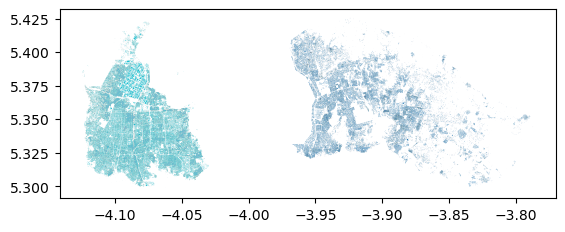

In [6]:
## Check results of concat

# Verify all features are there
if len(buildings_yop)+len(buildings_bgv)==len(buildings):
    print("number of features OK!")
else:
    print("Check features (incoherent number of lines after concat operation)")

# Verify all values (IDs) are unique
if buildings["id"].is_unique is True:
    print("ID column OK!")
else:
    print("ID column has duplicate values >> changing to index")
    buildings["id"] = buildings.index.to_list()
    if buildings["id"].is_unique is True:
        print("ID column OK!")
    else:
        print("Check ID column")

# Verify spatial output
buildings.plot(column="commune")

In [7]:
## Check geometry column

# Check geometry validity
empty_gm = buildings[buildings.geometry.is_empty].copy().shape[0]
nan_gm = buildings[buildings.geometry.isna()].copy().shape[0]
invalid_gm = buildings[~buildings.geometry.is_valid].shape[0]
if empty_gm+nan_gm+invalid_gm==0:
    print("Geoms are valid!")
else:
    print("Check geoms:")
    print("-----------------------")
    print("Empty geoms:",empty_gm)
    print("NaN geoms:",nan_gm)
    print("Invalid geoms:",invalid_gm)

# Ensure all geometries are polygons
if buildings.geom_type.unique()[0]=="Polygon" and buildings.geom_type.unique().shape[0]==1:
    print("All geoms are polygons - OK!")
else:
    print("Check geom types:")
    print("-----------------------")
    print("Geometry types:")
    buildings.geom_type.value_counts()
    # correct if necessary: buildings = buildings[buildings.geom_type == "Polygon"].reset_index(drop=True)

Geoms are valid!
All geoms are polygons - OK!


In [8]:
## Change CRS

# To local CRS
buildings = buildings.to_crs(local_crs)

In [9]:
## Area filter — remove buildings smaller than 20 m²
# Structures below this threshold are typically sheds, kiosks, or digitising artefacts
# that would distort morphometric statistics (mean area, density, alignment).
n_before = len(buildings)
buildings = buildings[buildings.area >= 20].reset_index(drop=True)
n_removed = n_before - len(buildings)
print(f"Buildings removed (area < 20 m²): {n_removed:,}  ({n_removed/n_before:.1%})")
print(f"Buildings remaining: {len(buildings):,}")

Buildings removed (area < 20 m²): 74,473  (18.3%)
Buildings remaining: 332,325


In [10]:
## Topology check — duplicate geometries and overlapping polygons

# 1. Duplicate geometries (identical shape, possibly different ID)
# shapely.to_wkb() operates at C level — much faster than apply(lambda g: g.wkb)
wkb = pandas.Series(shapely.to_wkb(buildings.geometry.values), index=buildings.index)
dup_mask = wkb.duplicated(keep='first')
n_dup = dup_mask.sum()
if n_dup > 0:
    print(f"Duplicate geometries found: {n_dup:,} — removing.")
    buildings = buildings[~dup_mask].reset_index(drop=True)
else:
    print("No duplicate geometries.")

# 2. Overlapping polygons (pairs whose interiors intersect, not just touch)
# Uses a spatial index (STRtree) for efficiency — avoids O(n²) brute-force.
overlap_pairs = shapely.STRtree(buildings.geometry).query(
    buildings.geometry, predicate='overlaps'
)
n_overlaps = overlap_pairs.shape[1] // 2  # each pair counted twice
if n_overlaps > 0:
    print(f"Overlapping polygon pairs found: {n_overlaps:,}")
else:
    print("No overlapping polygons.")

print(f"\nBuildings after topology check: {len(buildings):,}")

No duplicate geometries.
Overlapping polygon pairs found: 128,483

Buildings after topology check: 332,325


In [11]:
## Overlap resolution — largest polygon prevails, smaller is trimmed
#
# Strategy: sort by ORIGINAL area descending. For each building, subtract the union
# of all originally-larger buildings that still physically overlap it.
# "Originally larger" is determined from orig_areas (frozen) so that a heavily-
# trimmed large building does not lose its priority status over smaller neighbours.
# NOTE: predicate="intersects" catches both partial overlaps and full containment
# (shapely "overlaps" misses containment). Boundary-only touches are excluded via
# an explicit intersection-area > 0 check.
# Buildings fully absorbed (empty after difference) are dropped.
#
# After trimming, a negative buffer of 0.1 m is applied to ALL buildings.
# This cleanly eliminates any residual boundary-touching overlaps and floating-point
# slivers without further geometry surgery. Buildings that become empty after
# buffering (tiny slivers produced by the difference step) are also dropped.

geoms = buildings.geometry.values.copy()       # mutable; updated as buildings are trimmed
orig_areas = numpy.array([g.area for g in geoms])  # frozen — used for priority ranking
order = numpy.argsort(-orig_areas)             # process largest first

# Build tree from originals; stale entries are harmless because:
# • larger buildings are never modified → their tree entries are always correct
# • smaller buildings can only shrink → their stale entries may cause false-positive
#   candidate hits, which the area-check filters out
tree = shapely.STRtree(geoms)

for idx in order:
    g = geoms[idx]
    if g is None or g.is_empty:
        continue
    candidates = tree.query(g, predicate="intersects")
    larger = [
        c for c in candidates
        if c != idx
        and orig_areas[c] > orig_areas[idx]   # compare ORIGINAL areas — never updated
        and g.intersection(geoms[c]).area > 0  # exclude boundary-only touches
    ]
    if not larger:
        continue
    clip = shapely.unary_union([geoms[c] for c in larger])
    geoms[idx] = g.difference(clip)            # trim; do NOT update orig_areas

# Negative buffer: shrink every building by 0.1 m inward.
# Eliminates residual slivers and shared-boundary artifacts from the difference step.
geoms = shapely.buffer(geoms, -0.1, join_style="mitre")

# Remove buildings that became empty after trimming or buffering,
# or that shrank below 5 m² (slivers not meaningful as building footprints).
keep_mask = numpy.array(
    [g is not None and not g.is_empty and g.area >= 5 for g in geoms]
)
n_absorbed = (~keep_mask).sum()

buildings = buildings.copy()
buildings["geometry"] = geoms
buildings = buildings[keep_mask].reset_index(drop=True)

print(f"Overlap resolution + negative buffer complete.")
print(f"  Buildings removed (absorbed or collapsed to empty): {n_absorbed:,}")
print(f"  Buildings remaining: {len(buildings):,}")

# Verification re-check
geoms_after = buildings.geometry.values
tree_after = shapely.STRtree(geoms_after)
pairs = tree_after.query(geoms_after, predicate="intersects")
remaining = [
    (i, j) for i, j in zip(pairs[0], pairs[1])
    if i < j and geoms_after[i].intersection(geoms_after[j]).area > 0
]
print(f"  Remaining interior-overlapping pairs: {len(remaining):,}")


Overlap resolution + negative buffer complete.
  Buildings removed (absorbed or collapsed to empty): 49
  Buildings remaining: 332,276
  Remaining interior-overlapping pairs: 0


# Input data: street network

In [12]:
# Ensure WGS84 for OSMnx
boundary_wgs = boundary.to_crs(4326)

# Extract polygons from multipolygon
polygons = list(boundary_wgs.geometry[0].geoms)

graphs = []

for poly in polygons:
    # (1) Base drivable network. The "drive" filter already includes `residential`
    #     but EXCLUDES `service` roads, footways, tracks, etc.
    G = osmnx.graph_from_polygon(poly, network_type="drive")
    graphs.append(G)

    # (2) Additionally pull `service` + `residential` streets. `service` roads
    #     (alleys, parking aisles, internal lanes) are what subdivide the
    #     over-large blocks in 1-1; `residential` is included per request (already
    #     in `drive`, so compose_all just dedups it — harmless).
    #     - custom_filter overrides network_type (separate Overpass query).
    #     - retain_all=True keeps DISCONNECTED service stubs; without it OSMnx
    #       drops everything except the largest connected component, discarding
    #       most service segments and defeating the purpose.
    try:
        G_extra = osmnx.graph_from_polygon(
            poly,
            custom_filter='["highway"~"service|residential"]',
            retain_all=True,
        )
        graphs.append(G_extra)
    except Exception as e:
        # e.g. a polygon with no service/residential ways → nothing to add
        print(f"  no service/residential ways for one polygon ({type(e).__name__}); skipping")

# Combine graphs (compose_all unions by OSM node/edge id → shared nodes and any
# residential edges already present in `drive` are deduplicated automatically)
osm_graph = nx.compose_all(graphs)

# Project
osm_graph = osmnx.projection.project_graph(osm_graph, to_crs=local_crs)

# Convert to edges GeoDataFrame
streets = osmnx.graph_to_gdfs(
    osmnx.convert.to_undirected(osm_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
).reset_index(drop=True)

display(streets.head())
print(f"Street segments: {len(streets):,}")
print("highway classes:", streets['highway'].astype(str).value_counts().head(12).to_dict())

,osmid,highway,lanes,maxspeed,oneway,reversed,length,geometry,from,to,name,bridge,access,junction,ref,service,tunnel,width,area
0,30602466,motorway_link,1,60,True,False,285.462535,"LINESTRING (384557.766 592093.956, 384452.275 ...",33320976,243780434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,744406537,motorway,3,60,True,False,431.034335,"LINESTRING (384557.766 592093.956, 384470.172 ...",33320976,243780442,Autoroute du Nord,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[30613350, 289925190, 289925192, 289925203, 30...",motorway,"[3, 4]",60,True,False,1073.284278,"LINESTRING (385547.626 592490.47, 385395.917 5...",338326945,33320976,Autoroute du Nord,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,396602893,motorway_link,2,60,True,False,336.092348,"LINESTRING (384417.014 592198.143, 384404.611 ...",243780434,243780442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[30602465, 30602470, 396602895]",motorway_link,3,60,False,True,502.503432,"LINESTRING (384682.743 591828.857, 384670.648 ...",243780019,243780434,Boulevard de la Paix,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Street segments: 42,427
highway classes: {'residential': 34136, 'service': 3812, 'tertiary': 2172, 'secondary': 1086, 'unclassified': 621, 'primary': 173, 'motorway_link': 99, 'motorway': 74, 'trunk': 65, "['residential', 'service']": 43, 'secondary_link': 37, 'trunk_link': 34}


In [13]:
# Using momepy to ensure we have proper network topology
streets = momepy.remove_false_nodes(streets)
streets = streets[["geometry"]]
streets

,geometry
0,"LINESTRING (384557.766 592093.956, 384452.275 ..."
1,"LINESTRING (384557.766 592093.956, 384470.172 ..."
2,"LINESTRING (384417.014 592198.143, 384404.611 ..."
3,"LINESTRING (384682.743 591828.857, 384670.648 ..."
4,"LINESTRING (384129.386 592043.551, 384099.35 5..."
...,...
42346,"LINESTRING (379564.347 591483.72, 379565.092 5..."
42347,"LINESTRING (381274.757 592075.549, 381275.557 ..."
42348,"LINESTRING (384690.167 591783.095, 384664.58 5..."
42349,"LINESTRING (385536.043 591981.457, 385588.564 ..."


In [14]:
# Explode streets into 2-point segments for street-alignment computation.
# Vectorised implementation using shapely array functions — avoids iterrows()
# which processes one row at a time in Python and is very slow on large networks.
def explode_to_segments(gdf):
    """Split every LineString into individual 2-point segments.

    Uses shapely.get_coordinates() to extract all vertices at once (C level),
    then builds segments from consecutive coordinate pairs that belong to the
    same geometry. ~10–50× faster than the iterrows() equivalent.
    """
    import numpy
    geoms = gdf.geometry.values

    # Extract all coordinates and the geometry index each belongs to
    all_coords, geom_idx = shapely.get_coordinates(geoms, return_index=True)

    # A valid segment connects coord[i] → coord[i+1] within the same geometry
    same_geom = geom_idx[:-1] == geom_idx[1:]
    starts = all_coords[:-1][same_geom]   # (M, 2) start points
    ends   = all_coords[1: ][same_geom]   # (M, 2) end points

    # Interleave start/end so shapely.linestrings gets pairs in order
    n_segs = len(starts)
    coords_flat = numpy.empty((n_segs * 2, 2), dtype=starts.dtype)
    coords_flat[0::2] = starts
    coords_flat[1::2] = ends
    indices = numpy.repeat(numpy.arange(n_segs), 2)

    segments = shapely.linestrings(coords_flat, indices=indices)
    return geopandas.GeoDataFrame(geometry=segments, crs=gdf.crs)

streets_segments = explode_to_segments(streets)
streets_segments

,geometry
0,"LINESTRING (384557.766 592093.956, 384452.275 ..."
1,"LINESTRING (384452.275 592088.033, 384434.966 ..."
2,"LINESTRING (384434.966 592088.106, 384420.032 ..."
3,"LINESTRING (384420.032 592089.856, 384405.326 ..."
4,"LINESTRING (384405.326 592095.564, 384393.449 ..."
...,...
111253,"LINESTRING (391974.731 592817.46, 391973.699 5..."
111254,"LINESTRING (391973.699 592823.653, 391968.361 ..."
111255,"LINESTRING (391968.361 592832.074, 391918.389 ..."
111256,"LINESTRING (391918.389 592896.221, 391869.312 ..."


# Morphometrics

## Tessellation

In [15]:
## Tesselation

# Set limits for Voronoi geometries
limit = momepy.buffered_limit(buildings, "adaptive")

# Generate tessellation
tessellation = momepy.morphological_tessellation(buildings, clip=limit)

# Check result
if tessellation.shape[0] == buildings.shape[0] is True:
    print("Tessellation OK!")
else:
    print("Duplicate buildings - check geoms")

Duplicate buildings - check geoms


In [16]:
# Number of tessellation cells (should be same than buildings)
tessellation.shape[0]

332272

In [17]:
# Number of buildings
buildings.shape[0]

332276

In [18]:
##  Drop buildings that did not result in cell

# Overlapping index (as tessellation output did not get unique building ids)
buildings_sel = buildings[buildings.index.isin(tessellation.index)]
buildings_sel

,id,commune,geometry
0,0,Yopougon-Attécoubé,"POLYGON ((383284.681 594780.228, 383261.522 59..."
1,1,Yopougon-Attécoubé,"POLYGON ((383349.931 594854.13, 383343.469 594..."
2,3,Yopougon-Attécoubé,"POLYGON ((383307.736 594872.649, 383302.767 59..."
3,4,Yopougon-Attécoubé,"POLYGON ((383298.591 594672.794, 383297.589 59..."
4,5,Yopougon-Attécoubé,"POLYGON ((383210.563 594895.908, 383201.703 59..."
...,...,...,...
332271,406793,Cocody-Bingerville,"POLYGON ((399135.226 590143.845, 399132.522 59..."
332272,406794,Cocody-Bingerville,"POLYGON ((399100.697 590148.735, 399091.594 59..."
332273,406795,Cocody-Bingerville,"POLYGON ((399047.96 590063.244, 399036.03 5900..."
332274,406796,Cocody-Bingerville,"POLYGON ((399112.467 590161.092, 399109.659 59..."


## Link streets to buildings and cells

In [19]:
# Link unique IDs of streets to buildings based on the nearest neighbor join
buildings_sel["street_index"] = momepy.get_nearest_street(
    buildings_sel, streets, max_distance=None
)
buildings_sel

,id,commune,geometry,street_index
0,0,Yopougon-Attécoubé,"POLYGON ((383284.681 594780.228, 383261.522 59...",10097.0
1,1,Yopougon-Attécoubé,"POLYGON ((383349.931 594854.13, 383343.469 594...",40453.0
2,3,Yopougon-Attécoubé,"POLYGON ((383307.736 594872.649, 383302.767 59...",10097.0
3,4,Yopougon-Attécoubé,"POLYGON ((383298.591 594672.794, 383297.589 59...",65.0
4,5,Yopougon-Attécoubé,"POLYGON ((383210.563 594895.908, 383201.703 59...",10097.0
...,...,...,...,...
332271,406793,Cocody-Bingerville,"POLYGON ((399135.226 590143.845, 399132.522 59...",31027.0
332272,406794,Cocody-Bingerville,"POLYGON ((399100.697 590148.735, 399091.594 59...",31027.0
332273,406795,Cocody-Bingerville,"POLYGON ((399047.96 590063.244, 399036.03 5900...",31027.0
332274,406796,Cocody-Bingerville,"POLYGON ((399112.467 590161.092, 399109.659 59...",31027.0


In [20]:
# Attach the network index to the tessellation cells
tessellation["street_index"] = buildings_sel["street_index"]

## Individual geometry measurements

In [21]:
# Dimensions
buildings_sel["building_area"] = buildings_sel.area
tessellation["tess_area"] = tessellation.area
streets["length"] = streets.length

In [22]:
# Shape complexity
buildings_sel["eri"] = momepy.equivalent_rectangular_index(buildings_sel)
buildings_sel["elongation"] = momepy.elongation(buildings_sel)
tessellation["convexity"] = momepy.convexity(tessellation)
streets["linearity"] = momepy.linearity(streets)
streets["continuity"] = momepy.COINS(streets).stroke_attribute()

In [23]:
# Spatial distribution
queen_1 = libpysal.graph.Graph.build_contiguity(tessellation, rook=False)
tessellation["covered_area"] = queen_1.describe(tessellation.area)["sum"]
buildings_sel["neighbor_distance"] = momepy.neighbor_distance(buildings_sel, queen_1)
queen_3 = queen_1.higher_order(3)
buildings_sel["interbuilding_distance"] = momepy.mean_interbuilding_distance(
    buildings_sel, queen_1, queen_3)
dist100 = graph.Graph.build_distance_band(buildings_sel.centroid, threshold=100)
buildings_sel["nnb_100m"] = momepy.neighbors(buildings_sel.geometry, dist100)
dist50 = graph.Graph.build_distance_band(buildings_sel.centroid, threshold=50)
buildings_sel["nnb_50m"] = momepy.neighbors(buildings_sel.geometry, dist50)

In [24]:
# Intensity
tessellation["car"] = buildings_sel.area / tessellation.area

In [25]:
# Orientation and alignment metrics
buildings_sel = buildings_sel.reset_index(drop=True)

# Standard orientation: momepy implementation, output in [0°, 45°].
# Kept as a separate variable — reused in cell 33 for str_align.
orientation = momepy.orientation(buildings_sel)

def orientation45(geometry):
    """Orientation folded to [0°, 22.5°] with 45° periodicity (4-fold symmetry).

    Fully independent reimplementation of momepy.orientation — not derived from
    the standard output — to guarantee values in [0°, 22.5°] without relying on
    the intermediate [0°, 45°] range produced by momepy's fold.

    The only change vs momepy source: the final fold uses % 45 instead of % 90,
    i.e. numpy.abs((angle_deg + 22.5) % 45 - 22.5).
    """
    geom_types = geometry.geom_type
    poly_mask = geom_types.str.contains("Polygon")
    line_mask = geom_types.str.contains("Line")
    result = numpy.full(len(geometry), numpy.nan, dtype=float)
    if poly_mask.any():
        bboxes = shapely.minimum_rotated_rectangle(geometry.geometry.loc[poly_mask])
        coords = shapely.get_coordinates(bboxes)
        pt0 = coords[::5]; pt1 = coords[1::5]
        result[poly_mask] = numpy.degrees(
            numpy.arctan2(pt1[:, 0] - pt0[:, 0], pt1[:, 1] - pt0[:, 1])
        )
    if line_mask.any():
        first = shapely.get_point(geometry.geometry, 0)
        last  = shapely.get_point(geometry.geometry, -1)
        pt0 = shapely.get_coordinates(first); pt1 = shapely.get_coordinates(last)
        result[line_mask] = numpy.degrees(
            numpy.arctan2(pt1[:, 0] - pt0[:, 0], pt1[:, 1] - pt0[:, 1])
        )
    return pandas.Series(
        numpy.abs((result + 22.5) % 45 - 22.5),
        index=geometry.index, dtype=float, name="orientation45",
    )

orientation45 = orientation45(buildings_sel)

# KNN-4: fixed 4-nearest-neighbour graph (Taubenböck et al. 2018)
knn4 = graph.Graph.build_knn(buildings_sel.centroid, k=4)

# Mean alignment: mean absolute angular difference to 4 KNN neighbours, [0°, 22.5°]
# Low  → similar orientations → formal, grid-like
# High → divergent orientations → informal, irregular
buildings_sel["nb_alignment_knn4"] = momepy.alignment(orientation45, knn4)

# Std alignment: spread of orientations among 4 KNN neighbours
# Vectorised: knn4 has exactly 4 neighbours per node → reshape sparse indices to (N, 4).
orientation_vals = orientation45.values
_sp = knn4.sparse.tocsr()
nb_idx = _sp.indices.reshape(len(buildings_sel), 4)
buildings_sel["nb_alignment_std_knn4"] = orientation_vals[nb_idx].std(axis=1)

print("nb_alignment_knn4  (0–22.5°):", buildings_sel["nb_alignment_knn4"].describe().to_dict())
print("nb_alignment_std_knn4:", buildings_sel["nb_alignment_std_knn4"].describe().to_dict())

nb_alignment_knn4  (0–22.5°): {'count': 332272.0, 'mean': 2.188563498604103, 'std': 2.560363804058142, 'min': 4.752845857325383e-06, '25%': 0.38737613060783915, '50%': 1.27111712965202, '75%': 3.0647043870685913, 'max': 21.975617328204557}
nb_alignment_std_knn4: {'count': 332272.0, 'mean': 1.77799647522394, 'std': 1.9219583000922313, 'min': 4.050274662340647e-06, '25%': 0.31201845338221273, '50%': 1.032234840927488, '75%': 2.6612132470605014, 'max': 10.859994011391086}


In [26]:
# Connectivity
graph = momepy.gdf_to_nx(streets)
graph = momepy.node_degree(graph)
graph = momepy.closeness_centrality(graph, radius=400, distance="mm_len")
graph = momepy.meshedness(graph, radius=400, distance="mm_len")
nodes, edges = momepy.nx_to_gdf(graph)

  0%|          | 0/30127 [00:00<?, ?it/s]

  0%|          | 0/30127 [00:00<?, ?it/s]

In [27]:
## Relations between buildings and street network

# Streets profile
profile = momepy.street_profile(streets, buildings_sel)
streets[profile.columns] = profile

# Get nodes and edges indexes for later processing steps
buildings_sel["strseg_index"] = momepy.get_nearest_street(
    buildings_sel, streets_segments, max_distance=50
)  # NaN for buildings > 50 m from any street segment → str_align = NaN
buildings_sel["edge_index"] = momepy.get_nearest_street(buildings_sel, edges)
buildings_sel["node_index"] = momepy.get_nearest_node(
    buildings_sel, nodes, edges, buildings_sel["edge_index"]
)

# Select the corresponding street (non-segmented) for each building
nearest_streets = streets.loc[buildings_sel["street_index"], "geometry"].reset_index(drop=True)

# Compute distance to nearest street
buildings_sel["dist_to_street"] = buildings_sel.geometry.distance(nearest_streets)

# Alignment with nearest street in OSM network
# str_align uses standard orientation (not orientation45) — reuses `orientation`
# computed in cell 31, avoiding a second pass over all building geometries.
# Buildings beyond 50 m have strseg_index = NaN → str_align = NaN.
valid = buildings_sel["strseg_index"].notna()
seg_orient = momepy.orientation(streets_segments)
buildings_sel["str_align"] = numpy.nan
buildings_sel.loc[valid, "str_align"] = momepy.street_alignment(
    orientation[valid],
    seg_orient,
    buildings_sel.loc[valid, "strseg_index"].astype(int),
).values

# Export geodata outputs

In [28]:
# Join all building-level metrics to tessellation before export.
# Tessellation cells have a 1-to-1 relationship with buildings, so every building
# metric is also a tessellation-cell metric. Storing them together produces a single
# all-in-one gpkg that the downstream notebooks can load directly
# without needing a separate building footprints file.
#
# Index note: buildings_sel was reset_index'd in cell 31; tessellation was not.
# We reset tessellation here to ensure positional alignment before column assignment.
tessellation = tessellation.reset_index(drop=True)

building_only_cols = [
    c for c in buildings_sel.columns
    if c != "geometry" and c not in tessellation.columns
]
for col in building_only_cols:
    series = buildings_sel[col]
    if series.dtype == object:
        series = pandas.to_numeric(series, errors='coerce')
    tessellation[col] = series.to_numpy()

print(f"Tessellation columns after join: {len(tessellation.columns)}")
print(sorted(tessellation.columns.tolist()))

Tessellation columns after join: 22
['building_area', 'car', 'commune', 'convexity', 'covered_area', 'dist_to_street', 'edge_index', 'elongation', 'eri', 'geometry', 'id', 'interbuilding_distance', 'nb_alignment_knn4', 'nb_alignment_std_knn4', 'neighbor_distance', 'nnb_100m', 'nnb_50m', 'node_index', 'str_align', 'street_index', 'strseg_index', 'tess_area']


In [29]:
# Export building footprints (enhanced wiith morpholgical variables)
gdf_exp = buildings_sel.set_crs(local_crs)
gdf_exp.to_file("data/temp/Abidjan_Building_Footprints_SelAOI_momepy_bdg.gpkg",
                driver="GPKG")

# Export tessellation cells (enhanced wiith morpholgical variables)
gdf_exp = tessellation.set_crs(local_crs)
gdf_exp.to_file("data/temp/Abidjan_Building_Footprints_SelAOI_momepy_tess.gpkg",
                driver="GPKG")

# Export network
gdf_exp = streets.set_crs(local_crs)
gdf_exp.to_file("data/temp/streets.gpkg",
                driver="GPKG")
gdf_exp = nodes.set_crs(local_crs)
gdf_exp.to_file("data/temp/nodes.gpkg",
                driver="GPKG")
gdf_exp = edges.set_crs(local_crs)
gdf_exp.to_file("data/temp/edges.gpkg",
                driver="GPKG")